# 01 — Quickstart: Ni²⁺ L-edge XAS from a Fortran reference file

This notebook shows the fastest path from a pre-computed ttmult `.ban_out`
file to a plotted L-edge XAS spectrum, using the `getXAS()` one-liner.
It mirrors the minimal example in `README.md` but adds plotting, a
reference overlay, and a small broadening sweep so you can see how each
knob moves the spectrum.

**What you'll learn**
- Which files the bootstrap pipeline needs.
- How to call `getXAS()` and plot the result.
- How the three broadening widths (`beam_fwhm`, `gamma1`, `gamma2`) shape
  the spectrum.

**Prerequisites**: `pip install -e .` from the repo root, plus matplotlib.
All reference data is committed under `tests/reference_data/`.

In [1]:
# Make the notebook runnable from anywhere: chdir to the repo root so
# that relative paths like 'tests/reference_data/...' resolve correctly
# whether you launched jupyter from the repo root or from notebooks/.
import os
from pathlib import Path
_here = Path.cwd()
for _anc in [_here, *_here.parents]:
    if (_anc / "multitorch").is_dir() and (_anc / "tests" / "reference_data").is_dir():
        os.chdir(_anc)
        break
print("working dir:", Path.cwd())

working dir: /Users/afollmer/Follmer_UCD/Follmer_Lab/Code/multiplets/multitorch


## 1. What files are in a ttmult fixture?

Each fixture in `tests/reference_data/` is a complete ttmult run output.
For the bootstrap pipeline we only actually need the `.ban_out` file —
the others are here for validation and for the pipeline walkthrough
notebook.

In [2]:
from pathlib import Path

REFROOT = Path("tests/reference_data/ni2_d8_oh")
for f in sorted(REFROOT.iterdir()):
    print(f"{f.name:24s}  {f.stat().st_size:>10,} bytes")

ni2_d8_oh.ban                    551 bytes
ni2_d8_oh.ban_out             15,796 bytes
ni2_d8_oh.rcn31_out           16,626 bytes
ni2_d8_oh.rme_rac             28,617 bytes
ni2_d8_oh.rme_rcg             64,407 bytes
ni2_d8_oh.xy                  17,800 bytes


- **`.rme_rcg`** — COWAN single-shell reduced matrix elements
  (output of `ttrcg`).
- **`.rme_rac`** — symmetry-reduced coupled blocks for each operator
  (output of `ttrac`).
- **`.ban`** — the "recipe": XHAM scaling, XMIX hybridization, charge-
  transfer energies, and the list of symmetry triads to diagonalize.
- **`.ban_out`** — the diagonalized eigenstates + transition matrices
  (output of `ttban_exact`). This is what `getXAS()` consumes.
- **`.xy`** — the reference broadened spectrum from pyctm, for
  validation.

## 2. One-liner: `getXAS()`

`getXAS(ban_output_path, ...)` is the high-level entry point that matches
the signature of the original `pyctm.getXAS`. It reads the `.ban_out`,
applies Boltzmann weighting, and broadens with a pseudo-Voigt.

In [3]:
import torch
import matplotlib.pyplot as plt
from multitorch.api.plot import getXAS

x, y = getXAS(
    str(REFROOT / "ni2_d8_oh.ban_out"),
    T=80.0,          # Kelvin — affects the Boltzmann population when max_gs > 1
    beam_fwhm=0.2,   # Gaussian FWHM (eV) — instrumental broadening
    gamma1=0.2,      # L3 lifetime FWHM (eV)
    gamma2=0.4,      # L2 lifetime FWHM (eV)
)

print(f"x: {tuple(x.shape)}  range [{float(x.min()):.2f}, {float(x.max()):.2f}] eV")
print(f"y: {tuple(y.shape)}  max {float(y.max()):.4f}")

x: (2000,)  range [9.54, 41.89] eV
y: (2000,)  max 1.1843


## 3. Plot against the pyctm reference

The reference `.xy` is in relative-energy coordinates (zero at the first
point). We align peaks so the shape comparison is apples-to-apples.

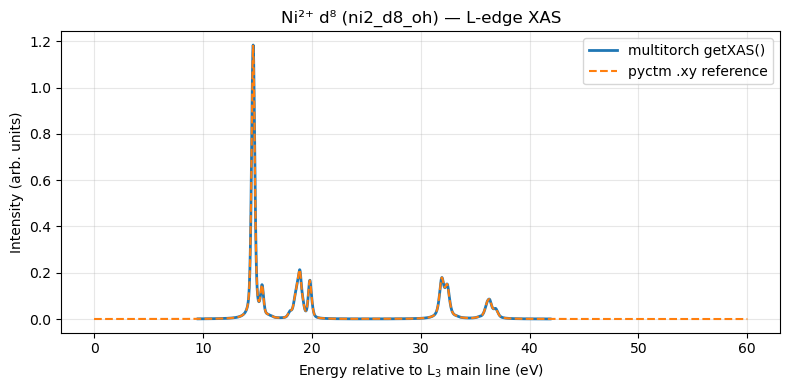

In [4]:
import numpy as np

xy_ref = np.loadtxt(str(REFROOT / "ni2_d8_oh.xy"))
x_ref, y_ref = xy_ref[:, 0], xy_ref[:, 1]

# Align peaks
x_np = x.detach().cpu().numpy()
y_np = y.detach().cpu().numpy()
shift = x_np[y_np.argmax()] - x_ref[y_ref.argmax()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_np - shift, y_np, label="multitorch getXAS()", lw=2)
ax.plot(x_ref, y_ref, "--", label="pyctm .xy reference", lw=1.5)
ax.set_xlabel("Energy relative to L$_3$ main line (eV)")
ax.set_ylabel("Intensity (arb. units)")
ax.set_title("Ni²⁺ d⁸ (ni2_d8_oh) — L-edge XAS")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. How each broadening width moves the spectrum

`beam_fwhm` controls the Gaussian instrumental width. `gamma1` and
`gamma2` are the Lorentzian lifetime widths for L₃ and L₂ respectively
(L₂ has a faster core-hole decay because of the Coster-Kronig channel,
hence a larger default). The pseudo-Voigt takes care of the transition
between them across the edge.

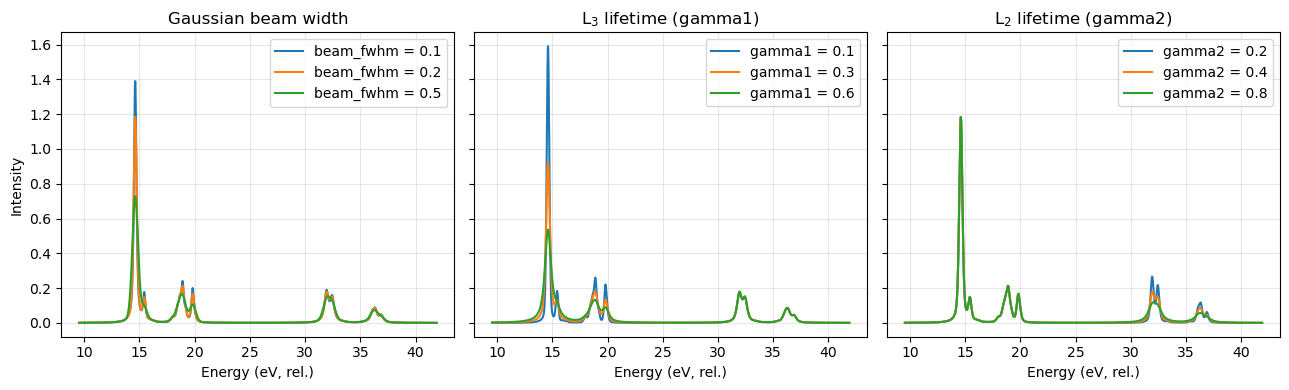

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

# (a) beam_fwhm sweep — Gaussian instrumental broadening
for bf in [0.1, 0.2, 0.5]:
    xb, yb = getXAS(str(REFROOT / "ni2_d8_oh.ban_out"),
                    beam_fwhm=bf, gamma1=0.2, gamma2=0.4)
    axes[0].plot(xb - shift, yb, label=f"beam_fwhm = {bf}")
axes[0].set_title("Gaussian beam width")
axes[0].set_xlabel("Energy (eV, rel.)")
axes[0].set_ylabel("Intensity")
axes[0].legend()
axes[0].grid(alpha=0.3)

# (b) gamma1 sweep — L3 lifetime
for g1 in [0.1, 0.3, 0.6]:
    xb, yb = getXAS(str(REFROOT / "ni2_d8_oh.ban_out"),
                    beam_fwhm=0.2, gamma1=g1, gamma2=0.4)
    axes[1].plot(xb - shift, yb, label=f"gamma1 = {g1}")
axes[1].set_title("L$_3$ lifetime (gamma1)")
axes[1].set_xlabel("Energy (eV, rel.)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# (c) gamma2 sweep — L2 lifetime
for g2 in [0.2, 0.4, 0.8]:
    xb, yb = getXAS(str(REFROOT / "ni2_d8_oh.ban_out"),
                    beam_fwhm=0.2, gamma1=0.2, gamma2=g2)
    axes[2].plot(xb - shift, yb, label=f"gamma2 = {g2}")
axes[2].set_title("L$_2$ lifetime (gamma2)")
axes[2].set_xlabel("Energy (eV, rel.)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Recap

- **Files needed**: just the `.ban_out` — everything else is provenance.
- **One call**: `getXAS(ban_path, T=..., beam_fwhm=..., gamma1=..., gamma2=...)`.
- **Outputs**: two `torch.Tensor`s on the CPU (float64 by default), ready
  to plot or feed into downstream analysis.

To explore the underlying layers (Wigner → RME → Hamiltonian →
broadening), continue with **`02_pipeline_walkthrough.ipynb`**.
To sweep physical parameters (10Dq, CT energy, temperature), continue
with **`03_parameter_exploration.ipynb`**.